In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os


/kaggle/input/datasets/shishiradh/stackoverflow-question-data-2020-2022/01_questions_base.parquet


In [ ]:
df = pd.read_parquet('../data/01_questions_base.parquet')
# df = pd.read_parquet("/kaggle/input/datasets/shishiradh/stackoverflow-question-data-2020-2022/01_questions_base.parquet")

In [4]:
# Creating the targets

df = df.copy()

# Classification target
df["is_answered"] = df["first_answer_date"].notna()

# Regression target
df["hours_to_first_answer"] = df["minutes_to_first_answer"]/60

In [5]:
leakage_cols = [
    # Direct answer outcomes
    "accepted_answer_id",
    "accepted_answer_date",
    "accepted_answer_score",
    "first_answer_date",
    "minutes_to_first_answer",
    "minutes_to_accepted_answer",

    # Answer-derived variables
    "answer_count",
    
    # Post-publication engagement
    "view_count",
    "comment_count",
    "question_score"
]

df = df.drop(columns=leakage_cols)

In [6]:
# Remove only invalid negative times. Keep unanswered questions with NaN response time.
df = df[
    df["hours_to_first_answer"].isna()
    | (df["hours_to_first_answer"] >= 0)
].copy()


# Question features
df["title_length"] = df["title"].str.len()

df["body_length"] = df["body"].str.len()

df['body_length_bucket'] = pd.qcut(df['body_length'], q=5, duplicates='drop').astype(str).astype('category')


df["has_code_block"] = df["body"].str.contains("<code>",regex=False).astype("int8")


# Tag features
df["tag_list"] = df["tags"].fillna("").str.split("|")
df["tag_list"] = df["tag_list"].apply(lambda tags: [t for t in tags if t])  # drop empty strings

df["num_tags"] = df["tag_list"].apply(len)
# Tag encoding remaining


# Time features
df["post_hour"] = df["creation_date"].dt.hour

df['post_month'] = df['creation_date'].dt.to_period('M')

df["post_hour_sin"] = np.sin(2* np.pi *df["post_hour"]/24)

df["post_hour_cos"] = np.cos(2* np.pi *df["post_hour"]/24)


# Asker account age
df["asker_account_age_days"] = (df["creation_date"] - df["asker_account_creation_date"]
                               ).dt.total_seconds()/86400



# Missingness Indicators
asker_cols = [
    "asker_reputation",
    "asker_upvote_count",
    "asker_downvote_count",
    "asker_account_age_days"
]

for col in asker_cols:
    df[f"{col}_missing"] = (df[col].isna().astype("int8"))

# Fill missing values
for col in asker_cols:
    df[col] = df[col].fillna(-1)



# Newcommer feature
df["is_new_asker"] = (df["asker_reputation"]<=1).astype("int8")



# Log-transform highly skewed asker features
df["asker_reputation_log"] = np.log1p(df["asker_reputation"].clip(lower=0))

df["asker_upvote_count_log"] = np.log1p(df["asker_upvote_count"].clip(lower=0))

df["asker_downvote_count_log"] = np.log1p(df["asker_downvote_count"].clip(lower=0))

df["asker_account_age_days_log"] = np.log1p(df["asker_account_age_days"].clip(lower=0))

/tmp/ipykernel_864/1159681157.py:30: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['post_month'] = df['creation_date'].dt.to_period('M')


In [7]:
# To remove right-censoring effect

buffer_days = 60
usable_cutoff = df['creation_date'].max() - pd.Timedelta(days=buffer_days)

print("Rows before trimming:", len(df))
df_trimmed = df[df['creation_date'] <= usable_cutoff].copy()
print("Rows after trimming:", len(df_trimmed))
print("Rows dropped:", len(df) - len(df_trimmed))

Rows before trimming: 3340696
Rows after trimming: 3054040
Rows dropped: 286656


## Training classification Model

In [57]:
# Chronological split:

model_df = df_trimmed.sort_values("creation_date").reset_index(drop=True)

train_end = int(len(model_df) * 0.70)
valid_end = int(len(model_df) * 0.80)

train_df = model_df.iloc[:train_end].copy()
valid_df = model_df.iloc[train_end:valid_end].copy()
test_df = model_df.iloc[valid_end:].copy()

In [59]:
# helper function
def get_tag_target_score(tag_list, tag_answer_rate, default_rate):
    
    scores = [
        tag_answer_rate.get(tag, default_rate)
        for tag in tag_list
        if tag
    ]
    
    if len(scores) == 0:
        return default_rate
    
    return np.mean(scores)

In [60]:
from sklearn.model_selection import TimeSeriesSplit

# Create empty column
train_df["tag_target_score"] = np.nan

# Chronological folds
tscv = TimeSeriesSplit(n_splits=5)

for past_idx, future_idx in tscv.split(train_df):

    # Earlier questions
    past_data = train_df.iloc[past_idx]

    # Later questions to encode
    future_data = train_df.iloc[future_idx]

    # Calculate tag answer rates using ONLY earlier questions
    past_exploded = past_data[
        ["question_id", "tag_list", "is_answered"]
    ].explode("tag_list")

    tag_answer_rate_fold = (
        past_exploded
        .groupby("tag_list")["is_answered"]
        .mean()
    )

    # Fallback for unseen tags
    global_answer_rate_fold = past_data["is_answered"].mean()

    # Apply historical rates to later questions
    train_df.loc[
        train_df.index[future_idx],
        "tag_target_score"
    ] = (
        future_data["tag_list"]
        .apply(
            lambda tags: get_tag_target_score(
                tags,
                tag_answer_rate_fold,
                global_answer_rate_fold
            )
        )
        .values
    )


train_df["tag_target_score"] = train_df["tag_target_score"].fillna(
    train_df["is_answered"].mean()
)

In [61]:
# Validation encoding
# Validation questions occur after training questions.
# Therefore, this is straightforward.
# Calculate tag answer rates using only training data:

train_exploded = train_df[
    ["question_id", "tag_list", "is_answered"]
].explode("tag_list")

tag_answer_rate = (
    train_exploded
    .groupby("tag_list")["is_answered"]
    .mean()
)

global_answer_rate = train_df["is_answered"].mean()


valid_df["tag_target_score"] = (
    valid_df["tag_list"]
    .apply(
        lambda tags: get_tag_target_score(
            tags,
            tag_answer_rate,
            global_answer_rate
        )
    )
)

In [62]:
# Test encoding
# For the test set, use the historical data available before the test period(TRAIN + VALIDATION).

train_valid_df = pd.concat(
    [train_df, valid_df],
    axis=0
)

train_valid_exploded = train_valid_df[
    ["question_id", "tag_list", "is_answered"]
].explode("tag_list")

tag_answer_rate_final = (
    train_valid_exploded
    .groupby("tag_list")["is_answered"]
    .mean()
)

global_answer_rate_final = (
    train_valid_df["is_answered"].mean()
)

test_df["tag_target_score"] = (
    test_df["tag_list"]
    .apply(
        lambda tags: get_tag_target_score(
            tags,
            tag_answer_rate_final,
            global_answer_rate_final
        )
    )
)

In [63]:
train_df['body_length_bucket'] = train_df['body_length_bucket'].astype(str).astype('category')
valid_df['body_length_bucket'] = valid_df['body_length_bucket'].astype(str).astype('category')
test_df['body_length_bucket'] = test_df['body_length_bucket'].astype(str).astype('category')


feature_cols = [
    'title_length', 'body_length', 'body_length_bucket', 'has_code_block', 'num_tags',
    'post_hour_sin', 'post_hour_cos',
    'asker_reputation_log', 'asker_upvote_count_log', 'asker_downvote_count_log',
    'asker_account_age_days_log', 'is_new_asker',
    'asker_reputation_missing', 'asker_upvote_count_missing',
    'asker_downvote_count_missing', 'asker_account_age_days_missing',
    'tag_target_score'
]

categorical_features = ['body_length_bucket']

X_train = train_df[feature_cols]
y_train = train_df['is_answered']
X_valid = valid_df[feature_cols]
y_valid = valid_df['is_answered']
X_test = test_df[feature_cols]
y_test = test_df['is_answered']

print(X_train.shape, X_valid.shape, X_test.shape)

(2137828, 17) (305404, 17) (610808, 17)


In [52]:
print(train_df['is_answered'].mean(), valid_df['is_answered'].mean(), test_df['is_answered'].mean())

0.7665443618476323 0.6394186061741169 0.6184791292844888


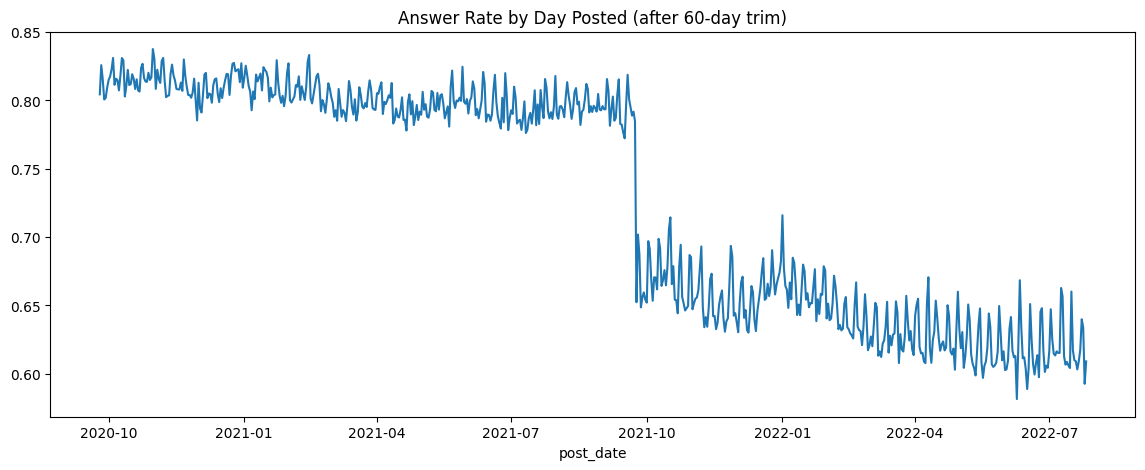

In [55]:
import matplotlib.pyplot as plt

df_trimmed['post_date'] = df_trimmed['creation_date'].dt.date
daily_rate_trimmed = df_trimmed.groupby('post_date')['is_answered'].mean()

daily_rate_trimmed.plot(figsize=(14,5), title='Answer Rate by Day Posted (after 60-day trim)')
plt.show()

## Initial Training

In [91]:
import lightgbm as lgb

train_data = lgb.Dataset(X_train, label = y_train, categorical_feature = categorical_features)
valid_data = lgb.Dataset(X_valid, label = y_valid, categorical_feature = categorical_features)

params = {
    'objective' : 'binary',
    'metric' : 'auc',
    'boosting_type' : 'gbdt',
    'num_leaves' : 31,
    'learning_rate' : 0.05,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq' : 5,
    'verbose' : -1
}

classification_model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, valid_data],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(50)]
)

Training until validation scores don't improve for 30 rounds


KeyboardInterrupt: 

## Test of initial training

In [66]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

y_pred_proba = classification_model.predict(X_test, num_iteration=classification_model.best_iteration)
y_pred = (y_pred_proba >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\n", classification_report(y_test, y_pred))

Accuracy: 0.662951369333735
Precision: 0.6652846472773706
Recall: 0.9157798883982932
F1: 0.7706887179989842
ROC-AUC: 0.7072425894385566

               precision    recall  f1-score   support

       False       0.65      0.25      0.36    233036
        True       0.67      0.92      0.77    377772

    accuracy                           0.66    610808
   macro avg       0.66      0.58      0.57    610808
weighted avg       0.66      0.66      0.62    610808



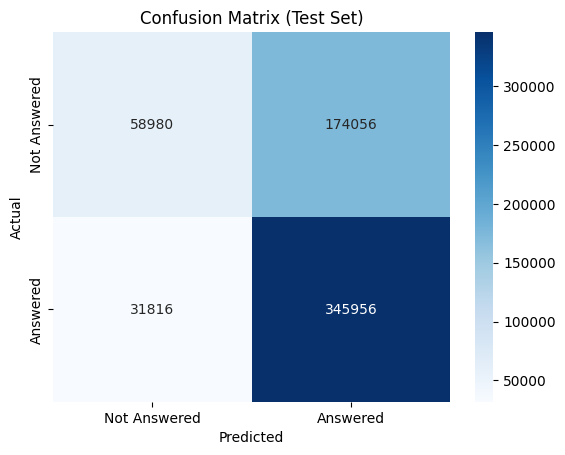

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Answered', 'Answered'],
            yticklabels=['Not Answered', 'Answered'])
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

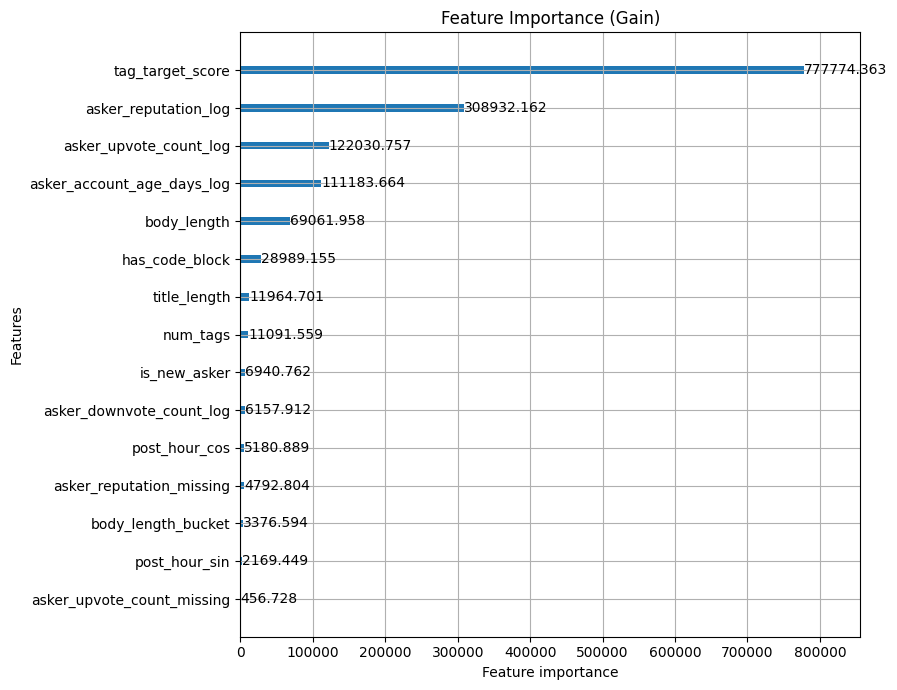

In [69]:
lgb.plot_importance(classification_model, max_num_features=17, importance_type='gain', figsize=(9,7))
plt.title('Feature Importance (Gain)')
plt.tight_layout()
plt.show()

In [77]:
from sklearn.metrics import f1_score

proba_valid = classification_model.predict(X_valid, num_iteration=classification_model.best_iteration)

threshold_options = np.arange(0.3, 0.8, 0.02)
results = []
for t in threshold_options:
    pred = (proba_valid >= t).astype(int)
    results.append({
        'threshold': t,
        'f1_answered': f1_score(y_valid, pred, pos_label=True),
        'f1_not_answered': f1_score(y_valid, pred, pos_label=False),
        'recall_not_answered': recall_score(y_valid, pred, pos_label=False),
        'precision_not_answered': precision_score(y_valid, pred, pos_label=False),
    })

threshold_df = pd.DataFrame(results)
print(threshold_df)

    threshold  f1_answered  f1_not_answered  recall_not_answered  \
0        0.30     0.780057         0.000018             0.000009   
1        0.32     0.780060         0.000054             0.000027   
2        0.34     0.780099         0.000817             0.000409   
3        0.36     0.780370         0.005917             0.002969   
4        0.38     0.781338         0.027400             0.013948   
5        0.40     0.783030         0.071693             0.037667   
6        0.42     0.784750         0.131095             0.072183   
7        0.44     0.786153         0.187616             0.108424   
8        0.46     0.786890         0.232958             0.140470   
9        0.48     0.786899         0.270267             0.169411   
10       0.50     0.786231         0.304393             0.198442   
11       0.52     0.785021         0.337618             0.229425   
12       0.54     0.783021         0.372994             0.265939   
13       0.56     0.779548         0.409879     

In [ ]:
del model_df

## Training after including recent-answer-rate feature

In [8]:
model_df = df_trimmed.sort_values('creation_date').reset_index(drop=True)

temp = model_df.set_index('creation_date')
rolling_rate = temp['is_answered'].rolling('30D').mean().shift(1)
model_df['recent_platform_answer_rate'] = rolling_rate.values

print("Rows with no rolling value yet:", model_df['recent_platform_answer_rate'].isna().sum())

Rows with no rolling value yet: 1


In [9]:
train_end = int(len(model_df) * 0.70)
valid_end = int(len(model_df) * 0.80)

train_df = model_df.iloc[:train_end].copy()
valid_df = model_df.iloc[train_end:valid_end].copy()
test_df = model_df.iloc[valid_end:].copy()

fallback_rate = train_df['is_answered'].mean()
for split_df in [train_df, valid_df, test_df]:
    split_df['recent_platform_answer_rate'] = split_df['recent_platform_answer_rate'].fillna(fallback_rate)

print(train_df.shape, valid_df.shape, test_df.shape)

(2137828, 33) (305404, 33) (610808, 33)


In [10]:
def get_tag_target_score(tag_list, tag_answer_rate, default_rate):
    scores = [tag_answer_rate.get(tag, default_rate) for tag in tag_list if tag]
    return np.mean(scores) if scores else default_rate

from sklearn.model_selection import TimeSeriesSplit

train_df['tag_target_score'] = np.nan
tscv = TimeSeriesSplit(n_splits=5)

for past_idx, future_idx in tscv.split(train_df):
    past_data = train_df.iloc[past_idx]
    future_data = train_df.iloc[future_idx]

    past_exploded = past_data[['question_id', 'tag_list', 'is_answered']].explode('tag_list')
    tag_answer_rate_fold = past_exploded.groupby('tag_list')['is_answered'].mean()
    global_answer_rate_fold = past_data['is_answered'].mean()

    train_df.loc[train_df.index[future_idx], 'tag_target_score'] = (
        future_data['tag_list']
        .apply(lambda tags: get_tag_target_score(tags, tag_answer_rate_fold, global_answer_rate_fold))
        .values
    )

train_df['tag_target_score'] = train_df['tag_target_score'].fillna(train_df['is_answered'].mean())

In [11]:
train_exploded = train_df[['question_id', 'tag_list', 'is_answered']].explode('tag_list')
tag_answer_rate = train_exploded.groupby('tag_list')['is_answered'].mean()
global_answer_rate = train_df['is_answered'].mean()

valid_df['tag_target_score'] = valid_df['tag_list'].apply(
    lambda tags: get_tag_target_score(tags, tag_answer_rate, global_answer_rate)
)

In [12]:
train_valid_df = pd.concat([train_df, valid_df], axis=0)
train_valid_exploded = train_valid_df[['question_id', 'tag_list', 'is_answered']].explode('tag_list')
tag_answer_rate_final = train_valid_exploded.groupby('tag_list')['is_answered'].mean()
global_answer_rate_final = train_valid_df['is_answered'].mean()

test_df['tag_target_score'] = test_df['tag_list'].apply(
    lambda tags: get_tag_target_score(tags, tag_answer_rate_final, global_answer_rate_final)
)

In [13]:
days_since_start = (train_df['creation_date'] - train_df['creation_date'].min()).dt.days
max_days = days_since_start.max()

decay_rate = 3.0
recency_weight = np.exp(decay_rate * (days_since_start / max_days - 1))

print("Weight range:", recency_weight.min(), "to", recency_weight.max())

Weight range: 0.049787068367863944 to 1.0


In [15]:
feature_cols = [
    'title_length', 'body_length', 'body_length_bucket', 'has_code_block', 'num_tags',
    'post_hour_sin', 'post_hour_cos',
    'asker_reputation_log', 'asker_upvote_count_log', 'asker_downvote_count_log',
    'asker_account_age_days_log', 'is_new_asker',
    'asker_reputation_missing', 'asker_upvote_count_missing',
    'asker_downvote_count_missing', 'asker_account_age_days_missing',
    'tag_target_score', 'recent_platform_answer_rate'
]
categorical_features = ['body_length_bucket']

X_train = train_df[feature_cols]
y_train = train_df['is_answered']
X_valid = valid_df[feature_cols]
y_valid = valid_df['is_answered']
X_test = test_df[feature_cols]
y_test = test_df['is_answered']

import lightgbm as lgb

train_data = lgb.Dataset(X_train, label=y_train, weight=recency_weight.values, categorical_feature=categorical_features)
valid_data = lgb.Dataset(X_valid, label=y_valid, categorical_feature=categorical_features, reference=train_data)

In [16]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}

model_v2 = lgb.train(
    params, train_data, num_boost_round=500,
    valid_sets=[train_data, valid_data], valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)]
)

Training until validation scores don't improve for 30 rounds
[50]	train's auc: 0.707719	valid's auc: 0.704595
[100]	train's auc: 0.711706	valid's auc: 0.707068
[150]	train's auc: 0.713625	valid's auc: 0.707867
[200]	train's auc: 0.714817	valid's auc: 0.708191
[250]	train's auc: 0.715703	valid's auc: 0.708249
Early stopping, best iteration is:
[255]	train's auc: 0.715808	valid's auc: 0.708262


In [20]:
from sklearn.metrics import f1_score, recall_score, precision_score

proba_valid = model_v2.predict(X_valid, num_iteration=model_v2.best_iteration)

threshold_options = np.arange(0.3, 0.8, 0.02)
results = []
for t in threshold_options:
    pred = (proba_valid >= t).astype(int)
    results.append({
        'threshold': t,
        'f1_answered': f1_score(y_valid, pred, pos_label=True),
        'f1_not_answered': f1_score(y_valid, pred, pos_label=False),
        'recall_not_answered': recall_score(y_valid, pred, pos_label=False),
        'precision_not_answered': precision_score(y_valid, pred, pos_label=False),
    })

threshold_df = pd.DataFrame(results)
threshold_df['macro_f1'] = (threshold_df['f1_answered'] + threshold_df['f1_not_answered']) / 2
print(threshold_df)

    threshold  f1_answered  f1_not_answered  recall_not_answered  \
0        0.30     0.785948         0.147575             0.082145   
1        0.32     0.786975         0.185258             0.106490   
2        0.34     0.787524         0.220947             0.131308   
3        0.36     0.788026         0.257801             0.158831   
4        0.38     0.787879         0.292423             0.187045   
5        0.40     0.787234         0.326156             0.217066   
6        0.42     0.786114         0.360002             0.250084   
7        0.44     0.784345         0.394336             0.287152   
8        0.46     0.780928         0.427436             0.328042   
9        0.48     0.776002         0.461243             0.375653   
10       0.50     0.768275         0.490177             0.424798   
11       0.52     0.758919         0.517020             0.477412   
12       0.54     0.746319         0.538450             0.529644   
13       0.56     0.731470         0.556176     

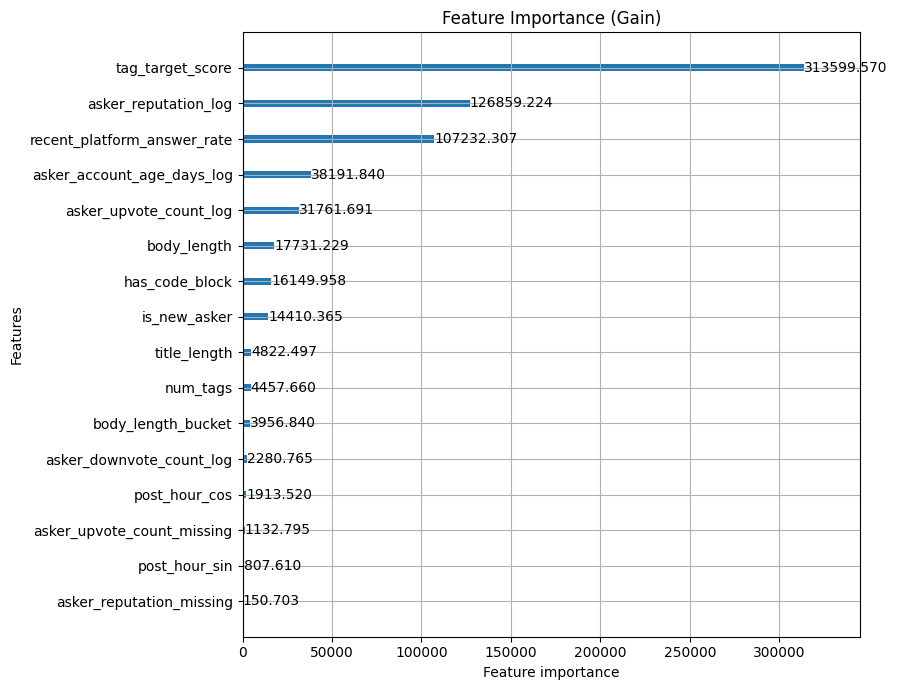

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

lgb.plot_importance(model_v2, max_num_features=17, importance_type='gain', figsize=(9,7))
plt.title('Feature Importance (Gain)')
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

FINAL_THRESHOLD = 0.56

proba_test = model_v2.predict(X_test, num_iteration=model_v2.best_iteration)
pred_test = (proba_test >= FINAL_THRESHOLD).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print(classification_report(y_test, pred_test))

ROC-AUC: 0.711204260998049
              precision    recall  f1-score   support

       False       0.53      0.68      0.60    233036
        True       0.76      0.63      0.69    377772

    accuracy                           0.65    610808
   macro avg       0.65      0.65      0.64    610808
weighted avg       0.67      0.65      0.65    610808



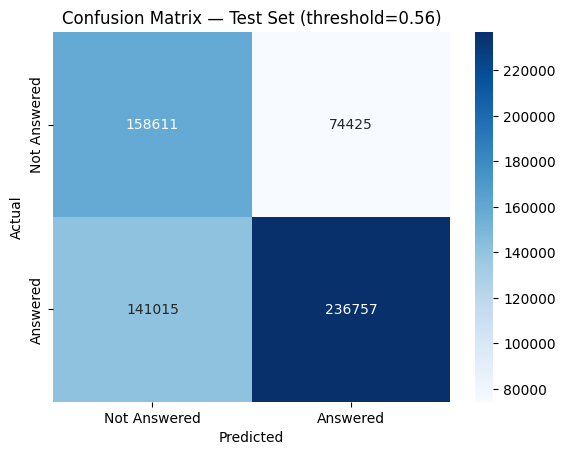

In [24]:
cm = confusion_matrix(y_test, pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Answered', 'Answered'],
            yticklabels=['Not Answered', 'Answered'])
plt.title(f'Confusion Matrix — Test Set (threshold={FINAL_THRESHOLD})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
model_v2.save_model('models/classification_model.txt')
print("Saved.")

Saved.


In [27]:
_, bin_edges = pd.qcut(train_df['body_length'], q=5, retbins=True, duplicates='drop')
print(bin_edges)

[3.70000e+01 5.81000e+02 9.48000e+02 1.45100e+03 2.42600e+03 1.15918e+05]


In [ ]:
import json

model_metadata = {
    'feature_cols': feature_cols,
    'categorical_features': categorical_features,
    'final_threshold': FINAL_THRESHOLD,
    'body_length_bucket_edges': bin_edges.tolist(),
}

with open('models/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print(model_metadata)

{'feature_cols': ['title_length', 'body_length', 'body_length_bucket', 'has_code_block', 'num_tags', 'post_hour_sin', 'post_hour_cos', 'asker_reputation_log', 'asker_upvote_count_log', 'asker_downvote_count_log', 'asker_account_age_days_log', 'is_new_asker', 'asker_reputation_missing', 'asker_upvote_count_missing', 'asker_downvote_count_missing', 'asker_account_age_days_missing', 'tag_target_score', 'recent_platform_answer_rate'], 'categorical_features': ['body_length_bucket'], 'final_threshold': 0.56, 'body_length_bucket_edges': [37.0, 581.0, 948.0, 1451.0, 2426.0, 115918.0]}


In [29]:
print(train_df.shape)
print(train_df['creation_date'].min(), train_df['creation_date'].max())
print(list(X_train.columns) == feature_cols)  # should be True

(2137828, 34)
2020-09-25 00:00:08.530000+00:00 2022-01-15 19:01:38.270000+00:00
True


In [30]:
import shap

explainer = shap.TreeExplainer(model_v2)
shap_values = explainer.shap_values(X_test)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [31]:
print(type(shap_values))
if isinstance(shap_values, list):
    print(len(shap_values), shap_values[0].shape)
else:
    print(shap_values.shape)

<class 'numpy.ndarray'>
(610808, 18)


In [32]:
# Normalize to a single array for everything below
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values
print(shap_vals.shape)  # should be (n_test_rows, n_features)

(610808, 18)


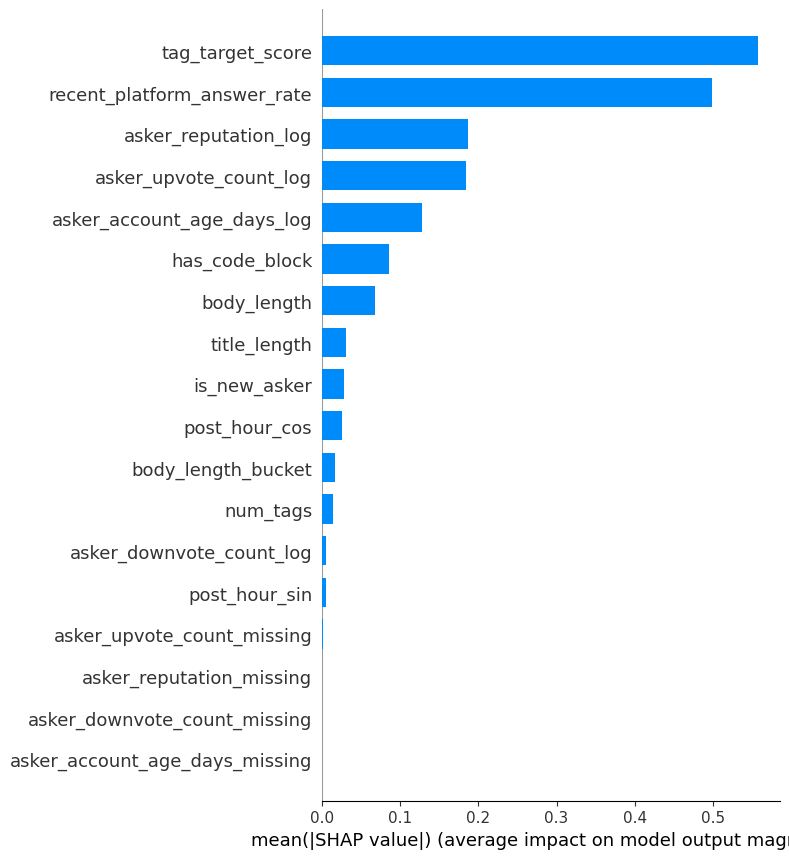

In [33]:
shap.summary_plot(shap_vals, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.show()

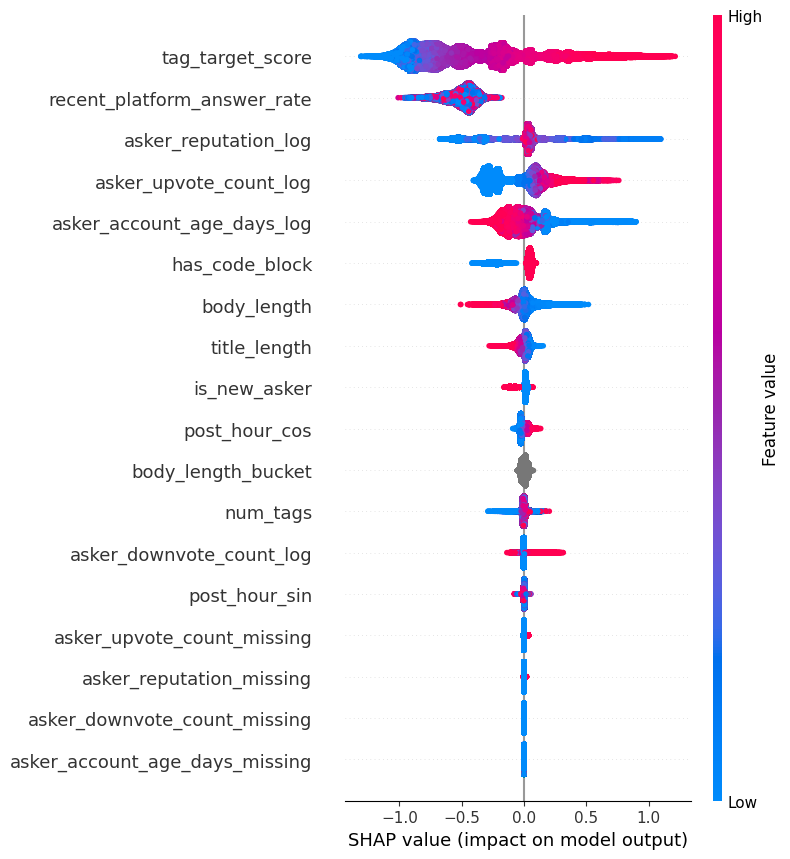

In [34]:
shap.summary_plot(shap_vals, X_test, show=False)
plt.tight_layout()
plt.show()

## Training Regression Model

In [60]:
# Regression-specific split, built fresh from df_trimmed
model_df_reg = df_trimmed.sort_values('creation_date').reset_index(drop=True)

temp = model_df_reg.set_index('creation_date')
rolling_speed = temp['hours_to_first_answer'].rolling('30D').median().shift(1)
model_df_reg['recent_platform_median_speed'] = rolling_speed.values
overall_fallback_speed = model_df_reg['hours_to_first_answer'].median()
model_df_reg['recent_platform_median_speed'] = model_df_reg['recent_platform_median_speed'].fillna(overall_fallback_speed)

# recompute recent_platform_answer_rate 
rolling_rate = temp['is_answered'].rolling('30D').mean().shift(1)
model_df_reg['recent_platform_answer_rate'] = rolling_rate.values
model_df_reg['recent_platform_answer_rate'] = model_df_reg['recent_platform_answer_rate'].fillna(
    model_df_reg['is_answered'].mean()
)

train_end_reg = int(len(model_df_reg) * 0.70)
valid_end_reg = int(len(model_df_reg) * 0.80)

train_df_reg_full = model_df_reg.iloc[:train_end_reg].copy()
valid_df_reg_full = model_df_reg.iloc[train_end_reg:valid_end_reg].copy()
test_df_reg_full = model_df_reg.iloc[valid_end_reg:].copy()

print("Columns confirmed present:",
      'recent_platform_median_speed' in train_df_reg_full.columns,
      'recent_platform_answer_rate' in train_df_reg_full.columns)

Columns confirmed present: True True


In [61]:
# tag encodings

train_df_reg_full['tag_target_score'] = np.nan
tscv = TimeSeriesSplit(n_splits=5)
for past_idx, future_idx in tscv.split(train_df_reg_full):
    past_data = train_df_reg_full.iloc[past_idx]
    future_data = train_df_reg_full.iloc[future_idx]
    past_exploded = past_data[['question_id', 'tag_list', 'is_answered']].explode('tag_list')
    tag_answer_rate_fold = past_exploded.groupby('tag_list')['is_answered'].mean()
    global_answer_rate_fold = past_data['is_answered'].mean()
    train_df_reg_full.loc[train_df_reg_full.index[future_idx], 'tag_target_score'] = (
        future_data['tag_list']
        .apply(lambda tags: get_tag_target_score(tags, tag_answer_rate_fold, global_answer_rate_fold))
        .values
    )
train_df_reg_full['tag_target_score'] = train_df_reg_full['tag_target_score'].fillna(train_df_reg_full['is_answered'].mean())

train_exploded_reg = train_df_reg_full[['question_id', 'tag_list', 'is_answered']].explode('tag_list')
tag_answer_rate_reg = train_exploded_reg.groupby('tag_list')['is_answered'].mean()
global_answer_rate_reg = train_df_reg_full['is_answered'].mean()

valid_df_reg_full['tag_target_score'] = valid_df_reg_full['tag_list'].apply(
    lambda tags: get_tag_target_score(tags, tag_answer_rate_reg, global_answer_rate_reg)
)

train_valid_reg = pd.concat([train_df_reg_full, valid_df_reg_full], axis=0)
train_valid_exploded_reg = train_valid_reg[['question_id', 'tag_list', 'is_answered']].explode('tag_list')
tag_answer_rate_final_reg = train_valid_exploded_reg.groupby('tag_list')['is_answered'].mean()
global_answer_rate_final_reg = train_valid_reg['is_answered'].mean()

test_df_reg_full['tag_target_score'] = test_df_reg_full['tag_list'].apply(
    lambda tags: get_tag_target_score(tags, tag_answer_rate_final_reg, global_answer_rate_final_reg)
)

In [62]:
train_reg = train_df_reg_full[train_df_reg_full['is_answered']].copy()
valid_reg = valid_df_reg_full[valid_df_reg_full['is_answered']].copy()
test_reg = test_df_reg_full[test_df_reg_full['is_answered']].copy()

feature_cols_reg = [
    'title_length', 'body_length', 'body_length_bucket', 'has_code_block', 'num_tags',
    'post_hour_sin', 'post_hour_cos','asker_reputation_log', 'asker_upvote_count_log', 'asker_downvote_count_log',
    'asker_account_age_days_log', 'is_new_asker','asker_reputation_missing', 'asker_upvote_count_missing',
    'asker_downvote_count_missing', 'asker_account_age_days_missing','tag_target_score', 
    'recent_platform_answer_rate', 'recent_platform_median_speed'
]
categorical_features_reg = ['body_length_bucket']

# Hard assertion — fail loudly now instead of mysteriously later
missing = [c for c in feature_cols_reg if c not in train_reg.columns]
assert not missing, f"Missing columns: {missing}"
print("All feature columns confirmed present.")

All feature columns confirmed present.


In [63]:
# Log-transform, clip, and build datasets:

train_reg['log_hours_to_answer'] = np.log1p(train_reg['hours_to_first_answer'])
valid_reg['log_hours_to_answer'] = np.log1p(valid_reg['hours_to_first_answer'])
test_reg['log_hours_to_answer'] = np.log1p(test_reg['hours_to_first_answer'])

lower_clip = train_reg['log_hours_to_answer'].quantile(0.01)
upper_clip = train_reg['log_hours_to_answer'].quantile(0.99)
for split_df in [train_reg, valid_reg, test_reg]:
    split_df['log_hours_clipped'] = split_df['log_hours_to_answer'].clip(lower_clip, upper_clip)

X_train_reg = train_reg[feature_cols_reg]
y_train_reg = train_reg['log_hours_clipped']
X_valid_reg = valid_reg[feature_cols_reg]
y_valid_reg = valid_reg['log_hours_clipped']
X_test_reg = test_reg[feature_cols_reg]
y_test_reg = test_reg['log_hours_to_answer']

days_since_start_reg = (train_reg['creation_date'] - train_reg['creation_date'].min()).dt.days
recency_weight_reg = np.exp(3.0 * (days_since_start_reg / days_since_start_reg.max() - 1))

train_data_reg = lgb.Dataset(X_train_reg, label=y_train_reg, weight=recency_weight_reg.values, categorical_feature=categorical_features_reg)
valid_data_reg = lgb.Dataset(X_valid_reg, label=y_valid_reg, categorical_feature=categorical_features_reg, reference=train_data_reg)

In [64]:
params_reg = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}

model_reg_clipped = lgb.train(
    params_reg, train_data_reg, num_boost_round=500,
    valid_sets=[train_data_reg, valid_data_reg], valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)]
)

params_quantile = {
    'objective': 'quantile', 'alpha': 0.5, 'metric': 'quantile',
    'boosting_type': 'gbdt', 'num_leaves': 31, 'learning_rate': 0.05,
    'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 5, 'verbose': -1
}

model_reg_quantile = lgb.train(
    params_quantile, train_data_reg, num_boost_round=500,
    valid_sets=[train_data_reg, valid_data_reg], valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)]
)

Training until validation scores don't improve for 30 rounds
[50]	train's rmse: 1.92846	valid's rmse: 1.88857
[100]	train's rmse: 1.91732	valid's rmse: 1.88143
[150]	train's rmse: 1.91316	valid's rmse: 1.87961
[200]	train's rmse: 1.91076	valid's rmse: 1.87921
Early stopping, best iteration is:
[212]	train's rmse: 1.91029	valid's rmse: 1.8791
Training until validation scores don't improve for 30 rounds
[50]	train's quantile: 0.641645	valid's quantile: 0.642284
[100]	train's quantile: 0.637033	valid's quantile: 0.640118
[150]	train's quantile: 0.635182	valid's quantile: 0.638291
[200]	train's quantile: 0.634232	valid's quantile: 0.637518
[250]	train's quantile: 0.633463	valid's quantile: 0.637093
Early stopping, best iteration is:
[249]	train's quantile: 0.633475	valid's quantile: 0.637087


In [65]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def evaluate_regression(model, name):
    pred_log = model.predict(X_test_reg, num_iteration=model.best_iteration)
    pred_hours = np.expm1(pred_log)
    actual_hours = np.expm1(y_test_reg)
    
    print(f"=== {name} ===")
    print("R² (log scale):", r2_score(y_test_reg, pred_log))
    print("Median Abs Error (hours):", np.median(np.abs(actual_hours - pred_hours)))
    print("MAE (hours):", mean_absolute_error(actual_hours, pred_hours))
    print()
    return pred_log

pred_clipped = evaluate_regression(model_reg_clipped, "Clipped L2 Regression")
pred_quantile = evaluate_regression(model_reg_quantile, "Quantile Regression (median)")

=== Clipped L2 Regression ===
R² (log scale): 0.06980267320568012
Median Abs Error (hours): 5.709471710304925
MAE (hours): 75.9675465064727

=== Quantile Regression (median) ===
R² (log scale): 0.08967423732314728
Median Abs Error (hours): 2.537182586945398
MAE (hours): 74.69309540976454



In [66]:
importance_df = pd.DataFrame({
    'feature': model_reg_quantile.feature_name(),
    'importance': model_reg_quantile.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)
print(importance_df)

                           feature    importance
16                tag_target_score  60984.840502
1                      body_length  18886.993217
3                   has_code_block  14289.684186
10      asker_account_age_days_log  12925.981289
4                         num_tags  11167.561139
7             asker_reputation_log   4595.309945
2               body_length_bucket   3610.767095
8           asker_upvote_count_log   3093.526384
6                    post_hour_cos   2665.615310
0                     title_length   1692.422071
17     recent_platform_answer_rate   1667.850408
5                    post_hour_sin    623.121673
18    recent_platform_median_speed    506.430042
9         asker_downvote_count_log    439.441011
11                    is_new_asker     67.703452
12        asker_reputation_missing     58.983681
13      asker_upvote_count_missing     31.977801
14    asker_downvote_count_missing      0.000000
15  asker_account_age_days_missing      0.000000


In [67]:
params_lower = params_quantile.copy()
params_lower['alpha'] = 0.1

params_upper = params_quantile.copy()
params_upper['alpha'] = 0.9

model_reg_lower = lgb.train(
    params_lower, train_data_reg, num_boost_round=500,
    valid_sets=[valid_data_reg], valid_names=['valid'],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)]
)

model_reg_upper = lgb.train(
    params_upper, train_data_reg, num_boost_round=500,
    valid_sets=[valid_data_reg], valid_names=['valid'],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)]
)

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[225]	valid's quantile: 0.157651
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[226]	valid's quantile: 0.426202


In [68]:
pred_lower = np.expm1(model_reg_lower.predict(X_test_reg, num_iteration=model_reg_lower.best_iteration))
pred_median = np.expm1(model_reg_quantile.predict(X_test_reg, num_iteration=model_reg_quantile.best_iteration))
pred_upper = np.expm1(model_reg_upper.predict(X_test_reg, num_iteration=model_reg_upper.best_iteration))

crossing_violations = (pred_lower > pred_median).sum() + (pred_median > pred_upper).sum()
print(f"Quantile crossing violations: {crossing_violations} out of {len(pred_median)} ({crossing_violations/len(pred_median):.2%})")

actual_hours_test = np.expm1(y_test_reg)
within_interval = (actual_hours_test >= pred_lower) & (actual_hours_test <= pred_upper)
print(f"Actual 80% interval coverage: {within_interval.mean():.1%}")

Quantile crossing violations: 22 out of 377772 (0.01%)
Actual 80% interval coverage: 81.4%


In [ ]:
model_reg_lower.save_model('models/regression_model_lower.txt')
model_reg_quantile.save_model('models/regression_model_median.txt')
model_reg_upper.save_model('models/regression_model_upper.txt')
print("All three regression models saved.")

All three regression models saved.


In [ ]:
import json

regression_metadata = {
    'feature_cols_reg': feature_cols_reg,
    'categorical_features_reg': categorical_features_reg,
    'quantile_alphas': {'lower': 0.1, 'median': 0.5, 'upper': 0.9},
    'log_clip_bounds': [float(lower_clip), float(upper_clip)],
    'interval_coverage_check': float(within_interval.mean()),
    'crossing_violation_rate': float(crossing_violations / len(pred_median))
}

with open('models/regression_metadata.json', 'w') as f:
    json.dump(regression_metadata, f, indent=2)

print(regression_metadata)

{'feature_cols_reg': ['title_length', 'body_length', 'body_length_bucket', 'has_code_block', 'num_tags', 'post_hour_sin', 'post_hour_cos', 'asker_reputation_log', 'asker_upvote_count_log', 'asker_downvote_count_log', 'asker_account_age_days_log', 'is_new_asker', 'asker_reputation_missing', 'asker_upvote_count_missing', 'asker_downvote_count_missing', 'asker_account_age_days_missing', 'tag_target_score', 'recent_platform_answer_rate', 'recent_platform_median_speed'], 'categorical_features_reg': ['body_length_bucket'], 'quantile_alphas': {'lower': 0.1, 'median': 0.5, 'upper': 0.9}, 'log_clip_bounds': [0.016529301951210565, 8.764696835256636], 'interval_coverage_check': 0.8140518619696536, 'crossing_violation_rate': 5.8236184788708535e-05}
